# CEF 2026 — Workshop Google Earth Engine + Python / Colab

## Détection de la perte de couvert forestier par télédétection


**Plateforme :** Google Colab + Google Earth Engine  
**Niveau requis :** aucune expérience préalable en Python ou GEE

---

### Qu'allons-nous faire ?

Ce notebook parcourt un pipeline complet de télédétection forestière :

1. Se connecter à **Google Earth Engine (GEE)** depuis Python
2. Charger une zone d'intérêt (la Forêt d'enseignement et de recherche du lac Duparquet — FERLD)
3. Construire des prédicteurs spectraux et topographiques (Sentinel-2, SRTM)
4. Utiliser le produit **Hansen Global Forest Change** comme étiquette de référence
5. Entraîner un **Random Forest** avec `scikit-learn`
6. Produire une carte complète via Earth Engine
7. Exporter les résultats (GeoTIFF, GeoJSON) pour QGIS

---

### Pourquoi « perte de forêt » et non « perturbation écologique » ?

Le produit Hansen détecte les **pertes de couvert arboré** (coupes, feux, chablis importants).  
Il ne capte **pas** toutes les formes de perturbation écologique subtile (perte de vigueur, chenilles, drainage).  
Les classes finales sont donc volontairement prudentes :

- `0` = aucune perte de forêt détectée (2001–2023)
- `1` = perte de forêt Hansen détectée (2001–2023)
- masqué = eau / hors zone d'intérêt

Nous utilisons le produit *Hansen Global Forest Change* (Université du Maryland) comme variable de référence parce qu'il constitue la seule source disponible à l'échelle mondiale avec une résolution de 30 m et une couverture annuelle continue depuis 2001. Il est dérivé de séries temporelles Landsat et détecte les pertes de couvert arboré — coupes, feux, chablis importants — à partir de changements spectraux brusques dans le proche infrarouge et le SWIR. Il est important de noter que ce produit ne capture pas toutes les formes de perturbation écologique subtile, et que dans le contexte boréal, les peuplements ouverts et les tourbières boisées peuvent être sous-représentés. C'est pourquoi nous l'interprétons strictement comme une étiquette de perte de forêt détectée, et non comme un inventaire exhaustif des perturbations

---

### Produits finaux

| Produit | Format | Usage |
|---|---|---|
| Modèle Random Forest | scikit-learn | Python / analyse |
| Métriques de validation | classification_report | Publication |
| Importance des variables | barplot | Interprétation |
| Carte RF complète | GeoTIFF 30 m | QGIS / SIG |
| Polygones vecteur | GeoJSON 30 m | QGIS / SIG |


## Étape 0 — Installation des bibliothèques

> **Colab** est un environnement temporaire : les bibliothèques doivent être réinstallées à chaque session.  
> Cette cellule ne prend qu'une minute. Vous verrez beaucoup de texte défiler — c'est normal.

**Bibliothèques installées :**

| Bibliothèque | Rôle |
|---|---|
| `earthengine-api` | Interface Python vers Google Earth Engine |
| `geemap` | Cartes interactives + utilitaires GEE |
| `geopandas` | Manipulation de données géospatiales vectorielles |
| `scikit-learn` | Machine learning (Random Forest) |
| `matplotlib` | Visualisation (graphiques) |
| `pandas` | Tableaux de données |
| `shapely` | Géométries vectorielles |


In [1]:
# ============================================================
# 0. Installation des dépendances
# ============================================================

!pip install -q earthengine-api geemap geopandas scikit-learn matplotlib pandas shapely


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.0 MB/s eta 0:00:00


## Étape 1 — Importation des bibliothèques

On charge en mémoire toutes les bibliothèques dont on aura besoin.  
**`import X`** = « rends disponible la bibliothèque X dans ce notebook ».  
**`from X import Y`** = « récupère uniquement la fonction/classe Y depuis X ».


In [2]:
# ============================================================
# 1. Importations
# ============================================================

from pathlib import Path                        # chemins de fichiers (Drive, outputs)

import ee                                       # Google Earth Engine — accès aux données satellitaires
import geemap                                   # cartes interactives + utilitaires GEE
import pandas as pd                             # tableaux de données (échantillons, résultats)
import geopandas as gpd                         # données géospatiales vectorielles (GeoJSON, GeoPackage)
import matplotlib.pyplot as plt                 # graphiques (importance des variables, matrice de confusion)

# scikit-learn — bibliothèque de référence pour l'apprentissage automatique en Python
# elle regroupe des dizaines de modèles (Random Forest, SVM, réseaux de neurones…)
# et tous les outils nécessaires pour les entraîner, les évaluer et les interpréter
from sklearn.ensemble import RandomForestClassifier   # modèle Random Forest
from sklearn.model_selection import train_test_split  # séparation entraînement / test
from sklearn.metrics import (
    confusion_matrix,          # tableau vrais/faux positifs et négatifs
    classification_report,     # précision, rappel, F1 par classe
    accuracy_score,            # précision globale
    ConfusionMatrixDisplay,    # visualisation graphique de la matrice
)

print("✓ Toutes les bibliothèques importées avec succès.")

✓ Toutes les bibliothèques importées avec succès.


## Étape 2 — Connexion à Google Drive

Colab tourne sur un serveur distant de Google. Pour lire et écrire des fichiers  
de façon permanente, on « monte » votre Google Drive comme un disque.

> Une fenêtre de permission va s'ouvrir → cliquez **Autoriser** → sélectionnez votre compte Google.

**Structure attendue dans votre Drive :**

```
My Drive/
└── Workshop/
    ├── Limits/
    │   └── FERLD.geojson      ← zone d'intérêt (fournie)
    └── Outputs/               ← créé automatiquement
```

https://drive.google.com/drive/folders/1MyP85Dc2lOKb29Btb-OcDiZiHHlNa81r?usp=sharing

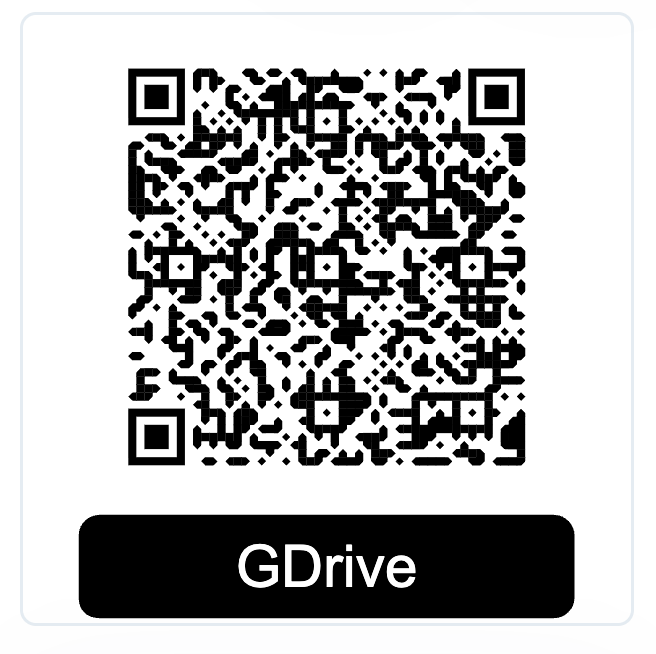

In [3]:
# ============================================================
# 2. Connexion à Google Drive et répertoires de travail
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

WORKDIR    = Path("/content/drive/MyDrive/Workshop")
LIMITS_DIR = WORKDIR / "Limits"
OUTPUT_DIR = WORKDIR / "Outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROI_PATH = LIMITS_DIR / "FERLD.geojson"

print("WORKDIR   :", WORKDIR)
print("ROI_PATH  :", ROI_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("ROI existe:", ROI_PATH.exists())

if not ROI_PATH.exists():
    raise FileNotFoundError(
        f"Fichier ROI introuvable : {ROI_PATH}\n"
        "Vérifiez que FERLD.geojson est bien dans MyDrive/Workshop/Limits/"
    )


Mounted at /content/drive
WORKDIR   : /content/drive/MyDrive/Workshop
ROI_PATH  : /content/drive/MyDrive/Workshop/Limits/FERLD.geojson
OUTPUT_DIR: /content/drive/MyDrive/Workshop/Outputs
ROI existe: True


## Étape 3 — Authentification Google Earth Engine

**Google Earth Engine (GEE)** est une plateforme cloud de géotraitement satellitaire.  
Elle donne accès à des pétaoctets d'images (Landsat, Sentinel, MODIS…) sans les télécharger.

Pour l'utiliser, il faut :
1. Un compte Google approuvé pour GEE (gratuit pour la recherche)
2. Un **projet Google Cloud** associé

> Si une fenêtre de connexion s'ouvre → connectez-vous avec le compte GEE enregistré.

> ⚠️ Si vous obtenez `EEException: project not found`, remplacez `PROJECT_ID` par l'identifiant  
> de votre propre projet Google Cloud.


In [5]:
# ============================================================
# 3. Authentification et initialisation de Earth Engine
# ============================================================

# Remplacez par votre propre projet Google Cloud si nécessaire.
PROJECT_ID = "gee-workshop-cef2026"

try:
    ee.Initialize(project=PROJECT_ID)
    print("✓ Earth Engine initialisé avec le projet :", PROJECT_ID)
except Exception as e:
    print("Initialisation échouée — lancement de l'authentification…")
    print("Erreur :", e)
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print("✓ Earth Engine authentifié et initialisé.")

# Test rapide : vérifier que l'API répond
test = ee.Number(1).add(1).getInfo()
print(f"✓ Test API Earth Engine : 1 + 1 = {test}  (attendu : 2)")


✓ Earth Engine initialisé avec le projet : gee-workshop-cef2026
✓ Test API Earth Engine : 1 + 1 = 2  (attendu : 2)


## Étape 4 — Chargement de la zone d'intérêt (ROI)

La **ROI** (*Region of Interest*) délimite l'espace d'analyse.  
Ici : la **Forêt d'enseignement et de recherche du lac Duparquet (FERLD)**, Abitibi-Témiscamingue.

**Pourquoi simplifier la géométrie ?**  
Les fichiers GeoJSON peuvent contenir des milliers de sommets.  
Avant d'envoyer la géométrie à Earth Engine, on la simplifie (~100 m de tolérance)  
pour éviter des erreurs de dépassement de mémoire.

La simplification est sauvegardée localement — l'original n'est pas modifié.


In [6]:
# ============================================================
# 4. Chargement et simplification de la ROI
# ============================================================

if not ROI_PATH.exists():
    raise FileNotFoundError(
        f"FERLD.geojson introuvable : {ROI_PATH}\n"
        "Vérifiez que le fichier est bien dans MyDrive/Workshop/Limits/\n"
        "et que Google Drive est monté (étape 2)."
    )

roi_gdf = gpd.read_file(ROI_PATH).to_crs("EPSG:4326")

roi_union = roi_gdf.dissolve().reset_index(drop=True)
roi_union["geometry"] = roi_union.geometry.simplify(
    tolerance=0.001,
    preserve_topology=True,
)

ROI_SIMPLIFIED_PATH = OUTPUT_DIR / "FERLD_simplified_for_ee.geojson"
roi_union.to_file(ROI_SIMPLIFIED_PATH, driver="GeoJSON")

roi_fc     = geemap.geojson_to_ee(str(ROI_SIMPLIFIED_PATH))
roi        = roi_fc.geometry()
roi_bounds = roi.bounds()

roi_outline = roi_fc.style(
    color="00ffff",
    fillColor="00000000",
    width=2,
)

Map = geemap.Map()
Map.add_basemap("SATELLITE")
Map.centerObject(roi_bounds, 11)
Map.addLayer(roi_outline, {}, "FERLD — zone d'intérêt")
Map

Map(center=[48.48109709314286, -79.3803974176913], controls=(WidgetControl(options=['position', 'transparent_b…

In [7]:
# ============================================================
# 4B. Expansion de la ROI — 10 km autour de la FERLD
# ============================================================

# On conserve la FERLD originale pour référence visuelle,
# et on crée une zone élargie de 10 km pour avoir suffisamment
# de pixels de perte Hansen pour entraîner le modèle.

roi_expanded = roi.buffer(10000).bounds()  # 10 km en mètres, bbox rectangulaire

roi_expanded_outline = ee.FeatureCollection([ee.Feature(roi_expanded)]).style(
    color="ffff00",
    fillColor="00000000",
    width=2,
)

Map = geemap.Map()
Map.add_basemap("SATELLITE")
Map.centerObject(roi_expanded, 9)
Map.addLayer(roi_expanded_outline, {}, "ROI élargie — 10 km")
Map.addLayer(roi_outline, {}, "FERLD originale")
Map

Map(center=[48.48106137490844, -79.3806271546655], controls=(WidgetControl(options=['position', 'transparent_b…

## Étape 5 — Construction des prédicteurs spectraux (Sentinel-2)

Les **prédicteurs** sont les variables d'entrée du modèle — l'équivalent des colonnes dans un tableau.  
Ils doivent être **indépendants de la variable réponse** (l'étiquette Hansen) pour éviter le *data leakage*.

### Pourquoi Sentinel-2 ?

Sentinel-2 (ESA) fournit des images multibandes à 10–20 m de résolution, toutes les 5 jours.  
On utilise une **composition médiane estivale (juin–septembre 2023)** pour obtenir  
une image sans nuages représentative de la végétation en saison de croissance.

### Masque nuageux (SCL)

La bande **SCL** (*Scene Classification Layer*) classe chaque pixel :  
ombres de nuage (3), nuages moyens (8), épais (9), cirrus (10), neige (11) → masqués.  
Les pixels valides sont divisés par 10 000 pour convertir en réflectance de surface (0–1).

### Bandes et indices utilisés

| Variable | Description | Résolution |
|---|---|---|
| B2 | Bleu (490 nm) | 10 m |
| B3 | Vert (560 nm) | 10 m |
| B4 | Rouge (665 nm) | 10 m |
| B8 | Proche infrarouge NIR (842 nm) | 10 m |
| B11 | SWIR 1 (1610 nm) | 20 m |
| B12 | SWIR 2 (2190 nm) | 20 m |
| **NDVI** | (NIR−Rouge)/(NIR+Rouge) — vigueur végétale | dérivé |
| **NDMI** | (NIR−SWIR1)/(NIR+SWIR1) — humidité foliaire | dérivé |


In [8]:
# ============================================================
# 5. Prédicteurs Sentinel-2 — composite médian estival
# ============================================================

# On travaille avec l'année 2023 — la plus récente disponible dans Hansen v1.11.
# Utiliser la même année que la période de perte maximale améliore la cohérence
# spectrale entre les prédicteurs et l'étiquette.
YEAR = 2023

# --- Fonction de masquage nuageux ---
# Chaque image Sentinel-2 contient une bande SCL (Scene Classification Layer)
# qui classe chaque pixel : végétation, sol nu, nuage, ombre, neige, eau…
# On retire les pixels non fiables AVANT de calculer le composite.
# Sans ce masque, les nuages introduisent des valeurs aberrantes dans le modèle.
def mask_s2_sr(image):
    """Masque les nuages, ombres et neige via la bande SCL."""
    scl = image.select("SCL")
    mask = (
        scl.neq(3)         # ombre de nuage
        .And(scl.neq(8))   # nuage moyen
        .And(scl.neq(9))   # nuage épais
        .And(scl.neq(10))  # cirrus
        .And(scl.neq(11))  # neige / glace
    )
    return (
        image
        .updateMask(mask)
        .divide(10000)     # les valeurs brutes Sentinel-2 sont en entiers × 10 000
                           # → division pour obtenir la réflectance réelle entre 0 et 1
        .copyProperties(image, ["system:time_start"])  # conserve la date de l'image
    )

# --- Construction du composite médian ---
# On ne travaille pas avec une seule image — on empile toutes les images
# de l'été 2023 sur la ROI, on applique le masque nuageux à chacune,
# puis on prend la MÉDIANE pixel par pixel.
# La médiane est plus robuste que la moyenne face aux valeurs extrêmes résiduelles.
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi_expanded)                             # uniquement les images qui couvrent la ROI
    .filterDate(f"{YEAR}-06-01", f"{YEAR}-09-30")          # saison de croissance — végétation active
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))   # pre-filtre : rejette les images trop nuageuses
    .map(mask_s2_sr)                                        # applique le masque pixel par pixel
    .median()                                               # composite médian sur toutes les images retenues
    .clip(roi_expanded)                                              # découpe au contour exact de la ROI
)

# --- Indices spectraux dérivés ---
# Ces indices combinent plusieurs bandes pour amplifier un signal biophysique spécifique.
# GEE calcule automatiquement (B8 - B4) / (B8 + B4) pour normalizedDifference.
ndvi = s2.normalizedDifference(["B8", "B4"]).rename("NDVI")   # vigueur de la végétation
ndmi = s2.normalizedDifference(["B8", "B11"]).rename("NDMI")  # teneur en eau foliaire

# --- Image prédictrice Sentinel-2 ---
# On sélectionne les 6 bandes spectrales les plus informatives pour la végétation forestière
# et on y ajoute les deux indices — 8 prédicteurs spectraux au total.
s2_predictors = (
    s2.select(["B2", "B3", "B4", "B8", "B11", "B12"])
    .addBands(ndvi)
    .addBands(ndmi)
)

# --- Images pour la visualisation cartographique (étapes 8 et 12B) ---
s2_rgb         = s2.select(["B4", "B3", "B2"])   # couleurs naturelles
s2_false_color = s2.select(["B12", "B8", "B4"])  # fausses couleurs SWIR — perturbations bien visibles

print("✓ Composite Sentinel-2 prêt.")
print(f"  Période : {YEAR}-06-01 → {YEAR}-09-30 | filtre nuages : ≤ 40 %")
print(f"  Bandes sélectionnées : B2, B3, B4, B8, B11, B12 + NDVI + NDMI")

✓ Composite Sentinel-2 prêt.
  Période : 2023-06-01 → 2023-09-30 | filtre nuages : ≤ 40 %
  Bandes sélectionnées : B2, B3, B4, B8, B11, B12 + NDVI + NDMI


## Étape 6 — Sélection des prédicteurs spectraux

On sélectionne les 8 bandes spectrales qui serviront d'entrée au modèle.
Les variables topographiques (élévation, pente) ont été exclues car elles
agissent comme proxy d'accessibilité humaine et non comme signal spectral
direct de perte forestière — ce qui biaiserait l'interprétation du modèle
et limiterait sa transférabilité à d'autres régions.

| Variable | Description |
|---|---|
| B2, B3, B4 | Bleu, Vert, Rouge — réflectance visible |
| B8 | Proche infrarouge NIR — biomasse foliaire |
| B11, B12 | SWIR — humidité et structure du couvert |
| NDVI | Vigueur végétale (NIR−Rouge)/(NIR+Rouge) |
| NDMI | Humidité foliaire (NIR−SWIR1)/(NIR+SWIR1) |

In [9]:
# ============================================================
# 6. Prédicteurs topographiques — SRTM
# ============================================================

dem   = ee.Image("USGS/SRTMGL1_003").clip(roi_expanded).rename("elevation")
slope = ee.Terrain.slope(dem).rename("slope")

PREDICTOR_BANDS = [
    "B2", "B3", "B4", "B8", "B11", "B12",
    "NDVI", "NDMI",
]


predictor_image_raw = (
    s2_predictors
    .select(PREDICTOR_BANDS)
    .toFloat()
)

print("✓ Image prédictrice complète prête.")
print(f"  {len(PREDICTOR_BANDS)} prédicteurs : {PREDICTOR_BANDS}")


✓ Image prédictrice complète prête.
  8 prédicteurs : ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDMI']


## Étape 7 — Domaine d'analyse et étiquette Hansen (variable réponse)

### Domaine d'analyse : ROI moins l'eau

On exclut les surfaces en eau permanente à l'aide du produit **JRC Global Surface Water**  
(occurrence ≥ 50 % = eau permanente). L'analyse ne porte que sur les pixels terrestres.

> **Pourquoi ne pas utiliser le masque de couvert arboré Hansen ?**  
> La forêt boréale inclut des pessières ouvertes, des tourbières boisées et des mosaïques  
> d'épinettes noires — formations que le seuil Hansen (≥ 10 % ou ≥ 25 % de couvert) peut exclure.  
> On préfère conserver tout le domaine terrestre et laisser le modèle apprendre.

### Variable réponse : perte de forêt Hansen

Le produit **Hansen Global Forest Change v1.11** (2023) enregistre, pour chaque pixel,  
l'année de première détection de perte de couvert arboré (2001–2023).

On construit une image binaire :
- `0` = aucune perte détectée entre 2001 et 2023
- `1` = perte détectée entre 2001 et 2023

> ⚠️ **Important :** l'image `ee.Image(0).where(...)` garantit que la classe 0 est explicitement  
> présente dans toute la zone d'analyse — sans cette ligne, les pixels sans perte resteraient  
> masqués et le modèle ne verrait qu'une seule classe.


In [10]:
# ============================================================
# 7. Domaine d'analyse + étiquette binaire de perte de forêt
# ============================================================

WATER_OCCURRENCE_THRESHOLD = 50   # % d'occurrence pour définir l'eau permanente
LOSS_START_YEAR = 2001
LOSS_END_YEAR   = 2023

# 1. Masque eau — JRC Global Surface Water
jrc_water  = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").clip(roi_expanded)
water_mask = jrc_water.gte(WATER_OCCURRENCE_THRESHOLD).rename("water")
non_water_mask = water_mask.Not().rename("non_water")

analysis_mask = non_water_mask.rename("analysis_mask")

# 2. Étiquette Hansen — perte de forêt binaire
hansen   = ee.Image("UMD/hansen/global_forest_change_2023_v1_11").clip(roi_expanded)
lossyear = hansen.select("lossyear")

start_code = LOSS_START_YEAR - 2000   # lossyear stocke 1, 2, ..., 23 (pas 2001, 2002...)
end_code   = LOSS_END_YEAR   - 2000

forest_loss_binary = lossyear.gte(start_code).And(lossyear.lte(end_code))

# 3. Image binaire finale : 0 partout, puis 1 là où il y a perte
#    IMPORTANT : créer 0 explicitement avant d'appliquer le masque
#    pour que la classe "sans perte" soit présente dans l'image.
forest_loss_label = (
    ee.Image(0)
    .where(forest_loss_binary, 1)
    .rename("forest_loss")
    .updateMask(analysis_mask)
    .toByte()
)

# 4. Appliquer le même masque aux prédicteurs
predictor_image = predictor_image_raw.updateMask(analysis_mask)

print("✓ Domaine d'analyse prêt : ROI moins l'eau.")
print(f"  Période de perte : {LOSS_START_YEAR}–{LOSS_END_YEAR}")
print(f"  Codes lossyear utilisés : {start_code} → {end_code}")


✓ Domaine d'analyse prêt : ROI moins l'eau.
  Période de perte : 2001–2023
  Codes lossyear utilisés : 1 → 23


## Étape 8 — Vérification visuelle

Avant de modéliser, on inspecte visuellement les données pour détecter des anomalies :

- **Fausses couleurs Sentinel-2 (SWIR-NIR-Rouge)** : la végétation saine apparaît en vert vif,  
  les coupes et perturbations en tons magenta/rose
- **Étiquette de perte Hansen** : orange = perte détectée; vert foncé = pas de perte
- **Masque eau** : bleu

> Utilisez les cases à cocher dans la légende de la carte pour activer/désactiver les couches.


In [11]:
# ============================================================
# 8. Vérification visuelle : contexte, eau, étiquette
# ============================================================

loss_palette  = ["1b7837", "d95f02"]   # vert foncé = pas de perte, orange = perte
water_palette = ["2b8cbe"]

Map = geemap.Map()
Map.add_basemap("SATELLITE")
Map.centerObject(roi_bounds, 11)

Map.addLayer(
    s2_false_color,
    {"bands": ["B12", "B8", "B4"], "min": 0.02, "max": 0.35, "gamma": 1.15},
    "Sentinel-2 fausses couleurs (SWIR-NIR-Rouge)",
    True,
)

Map.addLayer(
    ndvi,
    {"min": 0, "max": 1, "palette": ["f7f7f7", "d9f0a3", "78c679", "006837"]},
    "NDVI",
    False,
)

Map.addLayer(
    forest_loss_label,
    {"min": 0, "max": 1, "palette": loss_palette},
    "Étiquette Hansen : 0 = pas de perte, 1 = perte",
    True,
)

Map.addLayer(
    water_mask.updateMask(water_mask),
    {"palette": water_palette},
    "Masque eau",
    True,
)

Map.addLayer(roi_outline, {}, "FERLD — zone d'intérêt")

Map.add_legend(
    title="Légende",
    keys=["Pas de perte détectée", "Perte de forêt Hansen", "Eau", "Limite FERLD"],
    colors=["1b7837", "d95f02", "2b8cbe", "00ffff"],
)

Map


Map(center=[48.48109709314286, -79.3803974176913], controls=(WidgetControl(options=['position', 'transparent_b…

## Étape 9 — Échantillonnage stratifié équilibré

### Pourquoi échantillonner ?

Un modèle Random Forest n'entraîne pas directement sur des images raster — il apprend  
à partir d'un **tableau** où chaque ligne est un pixel et chaque colonne est un prédicteur.  
L'échantillonnage extrait ce tableau depuis les images Earth Engine.

### Échantillonnage stratifié

On tire **100 pixels par classe** (0 = pas de perte, 1 = perte), soit 200 pixels au total.  
L'équilibre est volontaire : la perte de forêt est rare dans le paysage,  
un tirage purement aléatoire produirait un jeu de données très déséquilibré  
et un modèle biaisé vers la classe majoritaire.




In [12]:
# ============================================================
# 8B. Déséquilibre des classes — pourquoi échantillonner à 400/400 ?
# ============================================================

# On compte les pixels de chaque classe dans la zone d'analyse (à 60 m pour aller vite)
class_counts = forest_loss_label.reduceRegion(
    reducer   = ee.Reducer.frequencyHistogram(),
    geometry  = roi_expanded,
    scale     = 60,
    maxPixels = 1e13,
    tileScale = 8,
)

counts = class_counts.getInfo()["forest_loss"]
n_stable = int(counts.get("0", 0))
n_loss   = int(counts.get("1", 0))
n_total  = n_stable + n_loss
ratio    = n_stable / n_loss if n_loss > 0 else float("inf")

print("Déséquilibre des classes dans la zone d'analyse (pixels 60 m)\n")
print(f"  Classe 0 — pas de perte : {n_stable:>8,}  ({n_stable/n_total:.1%})")
print(f"  Classe 1 — perte Hansen : {n_loss:>8,}  ({n_loss/n_total:.1%})")
print(f"  Ratio 0/1               : {ratio:.0f}x")
print()
print(f"→ Un tirage aléatoire pur donnerait ~{ratio:.0f} pixels sans perte")
print(f"  pour chaque pixel de perte.")
print(f"  Le modèle apprendrait à toujours prédire 0 et aurait quand même")
print(f"  {n_stable/n_total:.0%} de précision apparente — sans rien apprendre.")
print()
print(f"→ Solution : échantillonnage stratifié à 400 pixels par classe")
print(f"  pour forcer le modèle à apprendre les deux classes également.")

Déséquilibre des classes dans la zone d'analyse (pixels 60 m)

  Classe 0 — pas de perte :    7,794  (92.9%)
  Classe 1 — perte Hansen :      600  (7.1%)
  Ratio 0/1               : 13x

→ Un tirage aléatoire pur donnerait ~13 pixels sans perte
  pour chaque pixel de perte.
  Le modèle apprendrait à toujours prédire 0 et aurait quand même
  93% de précision apparente — sans rien apprendre.

→ Solution : échantillonnage stratifié à 400 pixels par classe
  pour forcer le modèle à apprendre les deux classes également.


### Longitude / latitude comme colonnes numériques

On ajoute les coordonnées géographiques comme **bandes numériques** (pas comme géométries).  
Cela permet d'exporter le tableau et de recréer les points spatiaux localement  
sans dépendre de l'extraction de géométries EE.

### `scale = 60 m`

L'échantillonnage est fait à 60 m (3× la résolution Sentinel-2 de 20 m).  
Cela réduit la corrélation spatiale entre pixels voisins et accélère l'extraction.

In [13]:
# ============================================================
# 9. Échantillonnage stratifié équilibré avec lon/lat
# ============================================================

SAMPLES_PER_CLASS = 400
SAMPLE_SCALE      = 60        # mètres — réduit l'autocorrélation spatiale

lonlat = ee.Image.pixelLonLat().select(["longitude", "latitude"])

training_stack = (
    predictor_image
    .addBands(forest_loss_label)
    .addBands(lonlat)
)

samples_ee = training_stack.stratifiedSample(
    numPoints    = 0,
    classBand    = "forest_loss",
    region       = roi_expanded,
    scale        = SAMPLE_SCALE,
    seed         = 42,
    classValues  = [0, 1],
    classPoints  = [SAMPLES_PER_CLASS, SAMPLES_PER_CLASS],
    dropNulls    = True,
    geometries   = False,
    tileScale    = 8,
)

# Télécharger le tableau depuis Earth Engine vers Python
try:
    features = samples_ee.getInfo()["features"]
except Exception as e:
    raise RuntimeError(
        "Échec de getInfo() — Earth Engine n'a pas pu extraire les échantillons.\n"
        "Causes possibles : quota dépassé, ROI trop large, ou connexion interrompue.\n"
        f"Erreur originale : {e}"
    )

rows = [f["properties"] for f in features]
df   = pd.DataFrame(rows)

required_cols = PREDICTOR_BANDS + ["forest_loss", "longitude", "latitude"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes après l'échantillonnage : {missing}")

df = df[required_cols].dropna().copy()
df["forest_loss"] = df["forest_loss"].astype(int)

print("✓ Tableau d'échantillons extrait.")
print(f"  Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print("\nÉquilibre des classes :")
print(df["forest_loss"].value_counts().sort_index().rename({0: "Pas de perte (0)", 1: "Perte (1)"}))

if df["forest_loss"].nunique() < 2:
    raise ValueError(
        "Une seule classe présente dans les échantillons.\n"
        "La perte de forêt Hansen est peut-être trop rare dans cette ROI.\n"
        "Solutions : agrandir la ROI, élargir la période, ou réduire le masque d'analyse."
    )

pd.concat([

    df[df["forest_loss"] == 0].head(5),
    df[df["forest_loss"] == 1].head(5),
]).reset_index(drop=True)


✓ Tableau d'échantillons extrait.
  Dimensions : 800 lignes × 11 colonnes

Équilibre des classes :
forest_loss
Pas de perte (0)    400
Perte (1)           400
Name: count, dtype: int64


,B2,B3,B4,B8,B11,B12,NDVI,NDMI,forest_loss,longitude,latitude
0,0.03300,0.03680,0.03360,0.05300,0.03690,0.01860,0.224018,0.179088,0,-79.178857,48.351371
1,0.05890,0.07735,0.07420,0.09090,0.03590,0.01690,0.101151,0.433754,0,-79.506023,48.610625
2,0.02975,0.04245,0.03050,0.20545,0.12695,0.06265,0.741471,0.236161,0,-79.447812,48.405270
3,0.03595,0.05445,0.03545,0.34015,0.20640,0.09690,0.811235,0.244717,0,-79.279109,48.416589
4,0.03785,0.04985,0.03805,0.23725,0.16710,0.07815,0.723574,0.173488,0,-79.362113,48.487196
5,0.03350,0.05140,0.03440,0.32950,0.16670,0.07450,0.810937,0.328093,1,-79.253237,48.514685
6,0.03190,0.03400,0.02770,0.05290,0.04270,0.02260,0.312655,0.106695,1,-79.571241,48.423057
7,0.02810,0.03660,0.03020,0.10260,0.05980,0.03180,0.545181,0.263547,1,-79.206345,48.534088
8,0.04530,0.07390,0.04750,0.32260,0.22750,0.12390,0.743313,0.172878,1,-79.185863,48.542173
9,0.05540,0.07760,0.06440,0.38490,0.21700,0.10350,0.713332,0.278950,1,-79.350255,48.549719


## Étape 10 — Random Forest avec scikit-learn

### Qu'est-ce qu'un Random Forest ?

Un **Random Forest** est un ensemble de nombreux arbres de décision entraînés chacun  
sur un sous-ensemble aléatoire des données et des variables.  
La prédiction finale est le vote majoritaire de tous les arbres.

Avantages pour la télédétection forestière :
- Robuste aux prédicteurs corrélés (NDVI et NIR, par exemple)
- Peu sensible à la mise à l'échelle des variables
- Produit une mesure d'importance des variables

### Séparation entraînement / test

On divise le tableau en :
- **70 % entraînement** → le modèle apprend ici
- **30 % test** → évaluation sur des données que le modèle n'a jamais vues

La stratification (`stratify=y`) garantit que la proportion 50/50 des classes  
est respectée dans les deux sous-ensembles.

### Paramètres clés

| Paramètre | Valeur | Explication |
|---|---|---|
| `n_estimators` | 300 | Nombre d'arbres |
| `class_weight` | `"balanced"` | Compense un éventuel déséquilibre résiduel |
| `max_features` | `"sqrt"` | Chaque arbre voit √10 ≈ 3 variables — réduit la corrélation entre arbres |
| `min_samples_leaf` | 3 | Évite le sur-apprentissage sur des pixels isolés |


Équilibre entraînement : {0: np.int64(280), 1: np.int64(280)}
Équilibre test         : {0: np.int64(120), 1: np.int64(120)}

Précision globale : 0.65

                       precision    recall  f1-score   support

Pas de perte détectée       0.65      0.67      0.66       120
Perte de forêt Hansen       0.66      0.63      0.64       120

             accuracy                           0.65       240
            macro avg       0.65      0.65      0.65       240
         weighted avg       0.65      0.65      0.65       240



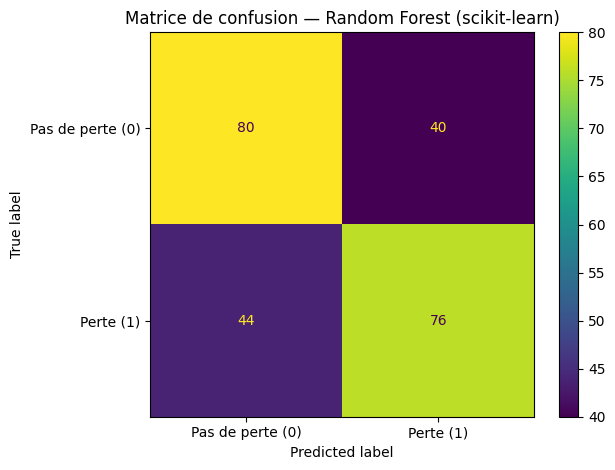

In [14]:
# ============================================================
# 10. Random Forest — scikit-learn
# ============================================================

X = df[PREDICTOR_BANDS].copy()
y = df["forest_loss"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.30,
    random_state = 42,
    stratify     = y,
)

rf_sklearn = RandomForestClassifier(
    n_estimators    = 300,
    random_state    = 42,
    class_weight    = "balanced",
    max_features    = "sqrt",
    min_samples_leaf= 3,
    n_jobs          = -1,
)

rf_sklearn.fit(X_train, y_train)
y_pred = rf_sklearn.predict(X_test)

print("Équilibre entraînement :", dict(y_train.value_counts().sort_index()))
print("Équilibre test         :", dict(y_test.value_counts().sort_index()))
print()
print("Précision globale :", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(
    y_test, y_pred,
    labels       = [0, 1],
    target_names = ["Pas de perte détectée", "Perte de forêt Hansen"],
    zero_division= 0,
))

cm   = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Pas de perte (0)", "Perte (1)"],
)
disp.plot(values_format="d")
plt.title("Matrice de confusion — Random Forest (scikit-learn)")
plt.tight_layout()
plt.show()


## Étape 11 — Importance des variables

L'importance des variables indique **dans quelle mesure chaque prédicteur contribue**
aux décisions du modèle (basé sur la réduction moyenne d'impureté de Gini).

> Une variable avec une importance élevée est fréquemment utilisée pour les divisions
> dans les arbres de décision et produit des nœuds plus purs.

### Résultat observé

La distribution est remarquablement uniforme (10–14 % par variable), ce qui indique
que le modèle exploite l'ensemble du spectre plutôt que de s'appuyer sur un seul signal.

**NDMI en tête (14 %)** — l'indice d'humidité foliaire est le prédicteur le plus
discriminant : une coupe ou un feu élimine l'eau contenue dans les feuilles,
provoquant une chute brutale du NDMI bien avant que le NDVI ne réagisse.

**Note méthodologique importante :** les prédicteurs ne sont pas indépendants.
NDVI et NDMI sont calculés à partir de B8, B4 et B11 qui figurent déjà dans le stack.
La même information spectrale est donc représentée sous plusieurs formes simultanément.
Pour un Random Forest cela ne pose pas de problème de convergence — l'algorithme
gère bien la multicolinéarité grâce à l'échantillonnage aléatoire des variables
(`max_features="sqrt"`). En revanche, l'importance de B8 est artificiellement
fragmentée entre B8, NDVI et NDMI, ce qui sous-estime sa contribution réelle.

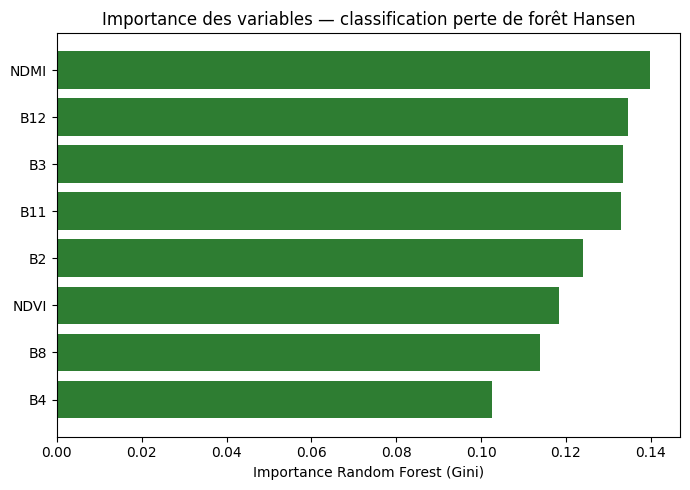


Ranking (décroissant) :
variable  importance
    NDMI    0.139915
     B12    0.134683
      B3    0.133496
     B11    0.133017
      B2    0.123939
    NDVI    0.118424
      B8    0.113937
      B4    0.102590


In [15]:
# ============================================================
# 11. Importance des variables
# ============================================================

importance = pd.DataFrame({
    "variable"  : PREDICTOR_BANDS,
    "importance": rf_sklearn.feature_importances_,
}).sort_values("importance", ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(importance["variable"], importance["importance"], color="#2e7d32")
plt.xlabel("Importance Random Forest (Gini)")
plt.title("Importance des variables — classification perte de forêt Hansen")
plt.tight_layout()
plt.show()

print("\nRanking (décroissant) :")
print(importance.sort_values("importance", ascending=False).to_string(index=False))


## Étape 12 — Carte complète par Random Forest Earth Engine

### Pourquoi deux modèles Random Forest ?

| | scikit-learn (étape 10) | Earth Engine RF (étape 12) |
|---|---|---|
| **Objectif** | Pipeline Python reproductible, métriques, interprétation | Carte complète à l'échelle du paysage |
| **Données** | Tableau tabulaire (~800 pixels) | Image raster entière (~millions de pixels) |
| **Avantage** | Flexibilité Python, visualisation | Calcul distribué sur les serveurs GEE |

Les deux modèles utilisent **exactement les mêmes échantillons et prédicteurs** (même `seed=42`).  
Ce n'est pas du *data leakage* — il n'y a pas d'évaluation croisée entre eux.  
Le modèle sklearn est évalué sur son propre split test (étape 10).  
Le modèle EE sert uniquement à la production cartographique.


In [16]:
# ============================================================
# 12. Random Forest Earth Engine — classification plein cadre
# ============================================================

ee_training_stack = predictor_image.addBands(forest_loss_label)

ee_samples = ee_training_stack.stratifiedSample(
    numPoints   = 0,
    classBand   = "forest_loss",
    region      = roi_expanded,
    scale       = SAMPLE_SCALE,
    seed        = 42,          # même seed → mêmes pixels qu'en étape 9
    classValues = [0, 1],
    classPoints = [SAMPLES_PER_CLASS, SAMPLES_PER_CLASS],
    dropNulls   = True,
    geometries  = False,
    tileScale   = 8,
)

rf_ee = ee.Classifier.smileRandomForest(
    numberOfTrees = 150,
    seed          = 42,
).train(
    features        = ee_samples,
    classProperty  = "forest_loss",
    inputProperties = PREDICTOR_BANDS,
)

classified_map = (
    predictor_image
    .classify(rf_ee)
    .rename("class")
    .toByte()
    .updateMask(analysis_mask)
    .clip(roi_expanded)
)

print("✓ Classification RF Earth Engine complète.")


✓ Classification RF Earth Engine complète.


### Carte finale — résultat de la classification


In [17]:
# ============================================================
# 12B. Carte finale : classification + contexte
# ============================================================

Map = geemap.Map()
Map.add_basemap("SATELLITE")
Map.centerObject(roi_expanded, 10)

Map.addLayer(
    s2_false_color,
    {"bands": ["B12", "B8", "B4"], "min": 0.02, "max": 0.35, "gamma": 1.15},
    "Sentinel-2 fausses couleurs (fond)",
    False,
)

Map.addLayer(
    classified_map,
    {"min": 0, "max": 1, "palette": loss_palette},
    "Carte RF : pas de perte / perte de forêt",
    True,
)

Map.addLayer(
    forest_loss_label,
    {"min": 0, "max": 1, "palette": ["ffffff", "d95f02"]},
    "Étiquette originale Hansen (référence)",
    False,
)

Map.addLayer(
    water_mask.updateMask(water_mask),
    {"palette": water_palette},
    "Masque eau",
    True,
)

Map.addLayer(roi_outline, {}, "FERLD — zone d'intérêt")

Map.add_legend(
    title="Classification perte de forêt",
    keys=["Pas de perte détectée", "Perte de forêt Hansen", "Eau", "Limite FERLD"],
    colors=["1b7837", "d95f02", "2b8cbe", "00ffff"],
)

Map


Map(center=[48.48106137490764, -79.38062715466576], controls=(WidgetControl(options=['position', 'transparent_…

## Étape 13 — Export des produits finaux

Earth Engine **ne peut pas écrire directement** dans le système de fichiers Colab.  
Les exports se font vers **Google Drive** via des tâches asynchrones.

**Chemin d'export Drive :** `My Drive / Workshop /`  
**Équivalent monté dans Colab :** `/content/drive/MyDrive/Workshop/`

> Les tâches s'exécutent en arrière-plan sur les serveurs Google, même après fermeture du notebook.  
> Durée typique : 1–5 minutes selon la taille de la zone.

> ⚠️ **CRS utilisé : EPSG:32618** (UTM zone 18N)  
> La FERLD se trouve en Abitibi-Témiscamingue — zone UTM 18N, pas 17N.  
> Vérifiez le CRS de vos données locales si vous combinez avec d'autres couches.


In [18]:
# ============================================================
# 13A. Export raster GeoTIFF
# ============================================================

EE_EXPORT_FOLDER = "Outputs"
EXPORT_PREFIX    = "FERLD_RF_forest_loss_no_loss"

export_tif_task = ee.batch.Export.image.toDrive(
    image           = classified_map,
    description     = f"{EXPORT_PREFIX}_TIF",
    folder          = EE_EXPORT_FOLDER,
    fileNamePrefix  = EXPORT_PREFIX,
    region          = roi_expanded,
    scale           = 30,
    crs             = "EPSG:32618",
    maxPixels       = 1e13,
)
export_tif_task.start()
print("✓ Export GeoTIFF démarré.")
print(export_tif_task.status())


✓ Export GeoTIFF démarré.
{'state': 'READY', 'description': 'FERLD_RF_forest_loss_no_loss_TIF', 'priority': 100, 'creation_timestamp_ms': 1779896145687, 'update_timestamp_ms': 1779896145687, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'ADQS5HAJG5G2A5FGUIMG4ICO', 'name': 'projects/gee-workshop-cef2026/operations/ADQS5HAJG5G2A5FGUIMG4ICO'}


In [19]:
# ============================================================
# 13B. Export vecteur GeoJSON (polygones)
# ============================================================

classified_vectors = classified_map.reduceToVectors(
    geometry       = roi_expanded,
    scale          = 30,
    geometryType   = "polygon",
    eightConnected = True,
    labelProperty  = "label",
    reducer        = ee.Reducer.countEvery(),
    maxPixels      = 1e13,
    tileScale      = 8,
    bestEffort     = True,
)

export_geojson_task = ee.batch.Export.table.toDrive(
    collection     = classified_vectors,
    description    = f"{EXPORT_PREFIX}_GeoJSON_30m",
    folder         = EE_EXPORT_FOLDER,
    fileNamePrefix = f"{EXPORT_PREFIX}_polygons_30m",
    fileFormat     = "GeoJSON",
)
export_geojson_task.start()
print("✓ Export GeoJSON polygones démarré.")
print("  Champ de classe dans le GeoJSON : 'label'  (0 = pas de perte, 1 = perte)")
print(export_geojson_task.status())


✓ Export GeoJSON polygones démarré.
  Champ de classe dans le GeoJSON : 'label'  (0 = pas de perte, 1 = perte)
{'state': 'READY', 'description': 'FERLD_RF_forest_loss_no_loss_GeoJSON_30m', 'priority': 100, 'creation_timestamp_ms': 1779896156033, 'update_timestamp_ms': 1779896156033, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': '4KMBM32XT3ISM7K4IRNUUDFF', 'name': 'projects/gee-workshop-cef2026/operations/4KMBM32XT3ISM7K4IRNUUDFF'}


In [20]:
# ============================================================
# 13C. Vérifier le statut + déplacer vers Workshop/Outputs
# Relancez jusqu'à COMPLETED, puis la cellule déplace les fichiers.
# ============================================================

from googleapiclient.discovery import build
from google.colab import auth

state_tif  = export_tif_task.status()["state"]
state_json = export_geojson_task.status()["state"]

print("Tâche GeoTIFF :", state_tif)
print("Tâche GeoJSON :", state_json)

if state_tif == "COMPLETED" and state_json == "COMPLETED":
    auth.authenticate_user()
    drive = build('drive', 'v3')
    DEST_FOLDER_ID = "1rVaB63IywTgkFn3dFCCY9009XiTI4uy2"

    def move_to_workshop_outputs(name_contains):
        results = drive.files().list(
            q=f"name contains '{name_contains}' and trashed=false",
            fields="files(id, name, parents)"
        ).execute()
        moved = []
        for f in results.get('files', []):
            if DEST_FOLDER_ID not in f.get('parents', []):
                drive.files().update(
                    fileId        = f['id'],
                    addParents    = DEST_FOLDER_ID,
                    removeParents = ','.join(f.get('parents', [])),
                    fields        = 'id, parents'
                ).execute()
                moved.append(f['name'])
                print(f"  ✓ Déplacé : {f['name']}")
        if not moved:
            print(f"  → Aucun fichier à déplacer pour '{name_contains}'")
        return moved

    print("\nDéplacement vers Workshop/Outputs :")
    move_to_workshop_outputs("FERLD_RF_forest_loss_no_loss")
else:
    print("\n→ Tâches encore en cours — relancez dans 30 secondes.")

Tâche GeoTIFF : RUNNING
Tâche GeoJSON : READY

→ Tâches encore en cours — relancez dans 30 secondes.


In [21]:
# ============================================================
# 13D. Lister tous les fichiers dans Workshop/Outputs
# ============================================================

print("Contenu de Workshop/Outputs :")
fichiers = [p for p in OUTPUT_DIR.rglob("*") if p.is_file() and not p.name.startswith(".")]
if fichiers:
    for p in sorted(fichiers):
        size_kb = p.stat().st_size / 1024
        print(f"  {size_kb:>8.1f} KB  {p.name}")
else:
    print("  (vide — relancez 13C ou 16F pour déplacer les fichiers depuis EE)")


Contenu de Workshop/Outputs :
      17.0 KB  FERLD_RF_forest_loss_no_loss.tif
       0.4 KB  FERLD_RF_forest_loss_no_loss.tif.aux.xml
    2422.1 KB  FERLD_RF_forest_loss_no_loss_polygons_30m (1).geojson
    2422.1 KB  FERLD_RF_forest_loss_no_loss_polygons_30m.geojson
     346.2 KB  FERLD_RF_forest_loss_training_samples.geojson
     248.0 KB  FERLD_RF_forest_loss_training_samples.gpkg
       8.0 KB  FERLD_simplified_for_ee.geojson
   11416.4 KB  FERLD_temporal_NDVI_2017.tif
       0.5 KB  FERLD_temporal_NDVI_2017.tif.aux.xml
   11408.1 KB  FERLD_temporal_NDVI_2020.tif
       0.5 KB  FERLD_temporal_NDVI_2020.tif.aux.xml
   11504.0 KB  FERLD_temporal_NDVI_2023.tif
       0.5 KB  FERLD_temporal_NDVI_2023.tif.aux.xml
      40.5 KB  FERLD_temporal_change_map_2017_2023.tif
    1082.5 KB  FERLD_temporal_change_map_2017_2023_polygons.geojson
   12479.1 KB  FERLD_temporal_delta_NDVI_2017_2023.tif
       0.5 KB  FERLD_temporal_delta_NDVI_2017_2023.tif.aux.xml


## Étape 14 — Export du tableau d'échantillons (optionnel)

Cette étape exporte le tableau de points utilisé par scikit-learn —  
**pas la carte classifiée**, mais les 800 pixels d'entraînement avec leurs coordonnées.

Utile pour :
- Vérifier la distribution spatiale des échantillons dans QGIS
- Réutiliser les données dans d'autres analyses Python/R
- Documentation et reproductibilité

Deux formats : **GeoJSON** (interopérable) et **GeoPackage** (recommandé pour QGIS).


In [22]:
# ============================================================
# 14. Export local du tableau d'échantillons scikit-learn
# ============================================================

gdf_samples = gpd.GeoDataFrame(
    df.copy(),
    geometry = gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs      = "EPSG:4326",
)

samples_geojson = OUTPUT_DIR / "FERLD_RF_forest_loss_training_samples.geojson"
samples_gpkg    = OUTPUT_DIR / "FERLD_RF_forest_loss_training_samples.gpkg"

gdf_samples.to_file(samples_geojson, driver="GeoJSON")
gdf_samples.to_file(samples_gpkg, layer="rf_samples", driver="GPKG")

print("✓ Fichiers exportés :")
print("  GeoJSON    :", samples_geojson)
print("  GeoPackage :", samples_gpkg)


✓ Fichiers exportés :
  GeoJSON    : /content/drive/MyDrive/Workshop/Outputs/FERLD_RF_forest_loss_training_samples.geojson
  GeoPackage : /content/drive/MyDrive/Workshop/Outputs/FERLD_RF_forest_loss_training_samples.gpkg


## Étape 15 — Ouverture des résultats dans QGIS

Une fois les tâches Earth Engine terminées (statut `COMPLETED` à l'étape 13C),  
les fichiers sont disponibles dans votre Google Drive.

**Méthode recommandée :** installez [Google Drive pour ordinateur](https://www.google.com/drive/download/)  
pour accéder aux fichiers comme un dossier local.

---

### GeoTIFF (raster 30 m)

`Couche → Ajouter une couche raster`

Fichier : `FERLD_RF_forest_loss_no_loss.tif`

Style suggéré : palette à deux classes
- Valeur `0` → vert foncé (`#1b7837`) — pas de perte détectée
- Valeur `1` → orange (`#d95f02`) — perte de forêt Hansen

---

### GeoJSON (polygones vectoriels 30 m)

`Couche → Ajouter une couche vecteur`

Fichier : `FERLD_RF_forest_loss_no_loss_polygons_30m.geojson`

> ⚠️ **Champ de classe : `label`** (et non `class`)  
> C'est le nom que Earth Engine assigne automatiquement lors de la vectorisation.

Style par le champ **`label`** :
- `0` → vert foncé (`#1b7837`) — pas de perte détectée
- `1` → orange (`#d95f02`) — perte de forêt Hansen
- Eau / hors ROI → masqué (absent du fichier)

> **Cohérence TIF / GeoJSON :** les deux produits sont générés à 30 m depuis la même  
> image classifiée — les polygones vectoriels correspondent aux pixels raster.

---

### Points d'échantillonnage (optionnel)

`Couche → Ajouter une couche vecteur`

Fichier : `FERLD_RF_forest_loss_training_samples.gpkg`

Style par le champ `forest_loss` — utile pour vérifier la distribution spatiale  
des pixels d'entraînement sur fond satellitaire.

---

> **CRS du projet QGIS :** utilisez `EPSG:32618` (UTM 18N) pour l'Abitibi-Témiscamingue.


---

## Étape 16 — Analyse temporelle : trois périodes + contraste Hansen

### Idée centrale

Jusqu'ici, le pipeline utilisait Sentinel-2 2023 comme **état spectral actuel**  
et Hansen comme étiquette — le modèle apprenait à reproduire Hansen.

Cette section fait quelque chose de différent :  
on compare **trois snapshots temporels** (2017 → 2020 → 2023) pour observer  
l'évolution du couvert forestier, puis on **contraste** nos résultats avec Hansen.

```
Sentinel-2 2017  ──┐
Sentinel-2 2020  ──┼──→  ΔNDVI par période  ──→  notre détection de changement
Sentinel-2 2023  ──┘                                        ↓
                                                  contraste avec Hansen
```

### Ce que chaque ΔNDVI révèle

| Variable | Interprétation |
|---|---|
| `ΔNDVI_2017_2020` | Changements entre les deux premières périodes |
| `ΔNDVI_2020_2023` | Changements récents |
| `ΔNDVI_2017_2023` | Bilan cumulé sur toute la période |

Valeur **négative** → perte de vigueur végétale → perturbation probable  
Valeur **positive** → gain de vigueur → régénération ou fermeture de couvert


In [ ]:
# ============================================================
# 16A. Trois composites Sentinel-2 — 2017, 2020, 2023
# ============================================================

# On réutilise la même fonction mask_s2_sr définie à l'étape 5.
# Même période saisonnière (juin–septembre) pour que les composites soient comparables.

def build_s2_composite(year):
    """Composite médian estival Sentinel-2 pour une année donnée."""
    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(roi_expanded)
        .filterDate(f"{year}-06-01", f"{year}-09-30")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
        .map(mask_s2_sr)
        .median()
        .clip(roi_expanded)
    )

s2_2017 = build_s2_composite(2017)
s2_2020 = build_s2_composite(2020)
s2_2023 = build_s2_composite(2023)

ndvi_2017 = s2_2017.normalizedDifference(["B8", "B4"]).rename("NDVI_2017")
ndvi_2020 = s2_2020.normalizedDifference(["B8", "B4"]).rename("NDVI_2020")
ndvi_2023 = s2_2023.normalizedDifference(["B8", "B4"]).rename("NDVI_2023")

print("✓ Composites prêts : 2017, 2020, 2023")


### Calcul des différences (ΔNDVI)

Un ΔNDVI négatif significatif (< −0.1) indique une perte de couvert détectable spectralement.  
On crée aussi une **image de changement cumulé** qui classe chaque pixel selon son évolution  
sur les trois périodes.


In [ ]:
# ============================================================
# 16B. ΔNDVI entre périodes
# ============================================================

delta_1720 = ndvi_2020.subtract(ndvi_2017).rename("dNDVI_2017_2020")
delta_2023 = ndvi_2023.subtract(ndvi_2020).rename("dNDVI_2020_2023")
delta_1723 = ndvi_2023.subtract(ndvi_2017).rename("dNDVI_2017_2023")  # bilan cumulé

# Seuil de détection : ΔNDVI < -0.10 = perte détectée, > +0.05 = gain détecté
LOSS_THRESHOLD = -0.10
GAIN_THRESHOLD =  0.05

# Image de changement cumulé (2017→2023) :
# 0 = stable, 1 = perte détectée, 2 = gain détecté
change_map = (
    ee.Image(0)                                          # stable par défaut
    .where(delta_1723.lt(LOSS_THRESHOLD), 1)             # perte
    .where(delta_1723.gt(GAIN_THRESHOLD), 2)             # gain
    .rename("change_2017_2023")
    .updateMask(analysis_mask)
    .toByte()
)

print("✓ ΔNDVI calculés.")
print(f"  Seuil perte : ΔNDVI < {LOSS_THRESHOLD}")
print(f"  Seuil gain  : ΔNDVI > {GAIN_THRESHOLD}")


In [ ]:
# ============================================================
# 16B2. Analyse numérique — superficie de changement par période
# ============================================================

SCALE   = 60    # mètres — suffisant pour les stats, rapide
AREA_M2 = ee.Image.pixelArea()

def surface_ha(image, label):
    """Calcule la superficie en ha pour chaque classe de changement."""
    results = {}
    for val, nom in [(0, "Stable"), (1, "Perte"), (2, "Gain")]:
        area = (
            AREA_M2
            .updateMask(image.eq(val))
            .reduceRegion(
                reducer  = ee.Reducer.sum(),
                geometry = roi_expanded,
                scale    = SCALE,
                maxPixels= 1e13,
                tileScale= 8,
            )
            .get("area")
        )
        results[nom] = round(ee.Number(area).divide(10000).getInfo(), 1)
    results["Période"] = label
    return results

# Calculer pour les trois périodes
rows = [
    surface_ha(change_map.where(
        delta_1720.lt(LOSS_THRESHOLD), 1).where(
        delta_1720.gt(GAIN_THRESHOLD), 2).rename("c"), "2017→2020"),
    surface_ha(change_map.where(
        delta_2023.lt(LOSS_THRESHOLD), 1).where(
        delta_2023.gt(GAIN_THRESHOLD), 2).rename("c"), "2020→2023"),
    surface_ha(change_map, "2017→2023 (cumulé)"),
]

df_stats = pd.DataFrame(rows).set_index("Période")[["Stable", "Perte", "Gain"]]
df_stats["Total (ha)"] = df_stats.sum(axis=1).round(1)
df_stats["% Perte"]   = (df_stats["Perte"]  / df_stats["Total (ha)"] * 100).round(1)
df_stats["% Gain"]    = (df_stats["Gain"]   / df_stats["Total (ha)"] * 100).round(1)

print("Superficie de changement ΔNDVI par période (ha)\n")
print(df_stats.to_string())

### Visualisation — les trois périodes + changement

La carte suivante superpose :
- Le **ΔNDVI cumulé 2017→2023** en dégradé (rouge = perte, bleu = gain)
- La **carte de changement** (perte / stable / gain)
- L'**étiquette Hansen** pour comparer

> Activez et désactivez les couches pour comparer visuellement  
> ce que Hansen détecte versus ce que le ΔNDVI révèle.


In [ ]:
# ============================================================
# 16C. Carte comparative — ΔNDVI + Hansen
# ============================================================

change_palette = ["f0f0f0", "d95f02", "1a9641"]   # stable, perte, gain

Map = geemap.Map()
Map.add_basemap("SATELLITE")
Map.centerObject(roi_bounds, 11)

# ΔNDVI cumulé en continu (dégradé)
Map.addLayer(
    delta_1723,
    {"min": -0.4, "max": 0.4, "palette": ["d73027", "f7f7f7", "1a9641"]},
    "ΔNDVI cumulé 2017→2023",
    True,
)

# Carte de changement discrète
Map.addLayer(
    change_map,
    {"min": 0, "max": 2, "palette": change_palette},
    "Changement 2017→2023 : stable / perte / gain",
    False,
)

# Hansen comme référence de contraste
Map.addLayer(
    forest_loss_label,
    {"min": 0, "max": 1, "palette": ["00000000", "d95f02"]},  # transparent + orange
    "Hansen forest loss (référence)",
    False,
)

Map.addLayer(roi_outline, {}, "FERLD — zone d'intérêt")

Map.add_legend(
    title="Légende",
    keys=["Perte ΔNDVI", "Stable", "Gain ΔNDVI", "Hansen forest loss"],
    colors=["d73027", "f7f7f7", "1a9641", "d95f02"],
)

Map


### Contraste quantitatif : ΔNDVI versus Hansen

Les cartes visuelles sont utiles, mais le contraste quantitatif est plus rigoureux.  
On croise les deux sources pixel par pixel pour identifier quatre situations :

| Situation | ΔNDVI | Hansen | Interprétation |
|---|---|---|---|
| **Accord — perte** | < −0.10 | 1 | Perte confirmée par les deux sources |
| **Hansen seul** | ≥ −0.10 | 1 | Hansen détecte, ΔNDVI ne confirme pas (régénération ?) |
| **ΔNDVI seul** | < −0.10 | 0 | Perturbation non capturée par Hansen (feu léger, défoliation) |
| **Accord — stable** | ≥ −0.10 | 0 | Pas de perturbation détectée |


In [ ]:
# ============================================================
# 16D. Contraste quantitatif ΔNDVI 2017→2023 vs Hansen
# ============================================================

# Binariser le ΔNDVI cumulé selon le seuil de perte
delta_loss_binary = delta_1723.lt(LOSS_THRESHOLD).rename("delta_loss")

# Empiler les deux couches et échantillonner
contrast_stack = (
    delta_loss_binary
    .addBands(forest_loss_label.rename("hansen_loss"))
    .updateMask(analysis_mask)
)

contrast_samples = contrast_stack.stratifiedSample(
    numPoints   = 0,
    classBand   = "hansen_loss",
    region      = roi_expanded,
    scale       = 60,
    seed        = 42,
    classValues = [0, 1],
    classPoints = [500, 500],
    dropNulls   = True,
    geometries  = False,
    tileScale   = 8,
)

try:
    cf = contrast_samples.getInfo()["features"]
except Exception as e:
    raise RuntimeError(f"Échec de l'échantillonnage de contraste : {e}")

df_contrast = pd.DataFrame([f["properties"] for f in cf])[["delta_loss", "hansen_loss"]].dropna().astype(int)

# Tableau de contingence
ct = pd.crosstab(
    df_contrast["delta_loss"].map({0: "ΔNDVI stable", 1: "ΔNDVI perte"}),
    df_contrast["hansen_loss"].map({0: "Hansen stable", 1: "Hansen perte"}),
)

print("Tableau de contingence ΔNDVI (2017→2023) × Hansen\n")
print(ct)
print()

# Accord global
accord = (df_contrast["delta_loss"] == df_contrast["hansen_loss"]).mean()
print(f"Accord global : {accord:.1%}")
print()

# Lecture par situation
n = len(df_contrast)
accord_perte  = ((df_contrast["delta_loss"]==1) & (df_contrast["hansen_loss"]==1)).sum()
hansen_seul   = ((df_contrast["delta_loss"]==0) & (df_contrast["hansen_loss"]==1)).sum()
delta_seul    = ((df_contrast["delta_loss"]==1) & (df_contrast["hansen_loss"]==0)).sum()
accord_stable = ((df_contrast["delta_loss"]==0) & (df_contrast["hansen_loss"]==0)).sum()

print(f"  Accord — perte   : {accord_perte:>4}  ({accord_perte/n:.1%})")
print(f"  Hansen seul      : {hansen_seul:>4}  ({hansen_seul/n:.1%})  ← Hansen détecte, ΔNDVI ne confirme pas")
print(f"  ΔNDVI seul       : {delta_seul:>4}  ({delta_seul/n:.1%})  ← perturbation non capturée par Hansen")
print(f"  Accord — stable  : {accord_stable:>4}  ({accord_stable/n:.1%})")


## Étape 16E — Export QGIS : trois produits cartographiques

Les cartes interactives Colab ont une résolution limitée et ne permettent pas  
d'inspecter les détails à l'échelle de la parcelle.

On exporte trois produits vers Google Drive pour les analyser dans QGIS :

| Produit | Format | Contenu |
|---|---|---|
| `FERLD_delta_NDVI_2017_2023.tif` | GeoTIFF 20 m | ΔNDVI continu — valeurs −1 à +1 |
| `FERLD_change_map_2017_2023.tif` | GeoTIFF 20 m | Discret : 0=stable, 1=perte, 2=gain |
| `FERLD_change_map_2017_2023_polygons.geojson` | GeoJSON | Polygones vectoriels par classe |

> **Styles QGIS recommandés :**  
> — ΔNDVI continu : rampe divergente rouge→blanc→vert, min=−0.4, max=0.4  
> — Carte discrète : 0=gris clair, 1=orange (`#d95f02`), 2=vert (`#1a9641`)  
> — Superposer la couche Hansen (`forest_loss_label`) pour le contraste visuel


In [ ]:
# ============================================================
# 16E. Export QGIS — ΔNDVI continu + carte de changement discrète
# ============================================================

EXPORT_FOLDER   = "Outputs"
PREFIX_TEMPORAL = "FERLD_temporal"

export_delta = ee.batch.Export.image.toDrive(
    image          = delta_1723.toFloat(),
    description    = f"{PREFIX_TEMPORAL}_delta_NDVI_2017_2023_TIF",
    folder         = EXPORT_FOLDER,
    fileNamePrefix = f"{PREFIX_TEMPORAL}_delta_NDVI_2017_2023",
    region         = roi_expanded,
    scale          = 20,
    crs            = "EPSG:32618",
    maxPixels      = 1e13,
)
export_delta.start()
print("✓ Export ΔNDVI continu démarré.")

export_change = ee.batch.Export.image.toDrive(
    image          = change_map.toByte(),
    description    = f"{PREFIX_TEMPORAL}_change_map_2017_2023_TIF",
    folder         = EXPORT_FOLDER,
    fileNamePrefix = f"{PREFIX_TEMPORAL}_change_map_2017_2023",
    region         = roi_expanded,
    scale          = 20,
    crs            = "EPSG:32618",
    maxPixels      = 1e13,
)
export_change.start()
print("✓ Export carte de changement démarré.")

change_vectors = change_map.reduceToVectors(
    geometry      = roi_expanded,
    scale         = 60,
    geometryType  = "polygon",
    eightConnected= True,
    labelProperty = "label",
    reducer       = ee.Reducer.countEvery(),
    maxPixels     = 1e13,
    tileScale     = 8,
    bestEffort    = True,
)
export_vectors = ee.batch.Export.table.toDrive(
    collection     = change_vectors,
    description    = f"{PREFIX_TEMPORAL}_change_map_2017_2023_GeoJSON",
    folder         = EXPORT_FOLDER,
    fileNamePrefix = f"{PREFIX_TEMPORAL}_change_map_2017_2023_polygons",
    fileFormat     = "GeoJSON",
)
export_vectors.start()
print("✓ Export polygones vectoriels démarré.")
print()
print("Statuts :")
print("  ΔNDVI    :", export_delta.status()["state"])
print("  Discret  :", export_change.status()["state"])
print("  Vecteurs :", export_vectors.status()["state"])


In [ ]:
# ============================================================
# 16F. Vérifier le statut + déplacer vers Workshop/Outputs
# Relancez jusqu'à COMPLETED, puis la cellule déplace les fichiers.
# ============================================================

from googleapiclient.discovery import build
from google.colab import auth

state_delta   = export_delta.status()["state"]
state_change  = export_change.status()["state"]
state_vectors = export_vectors.status()["state"]

print("ΔNDVI continu    :", state_delta)
print("Carte discrète   :", state_change)
print("Polygones vecteur:", state_vectors)

if all(s == "COMPLETED" for s in [state_delta, state_change, state_vectors]):
    auth.authenticate_user()
    drive = build('drive', 'v3')
    DEST_FOLDER_ID = "1rVaB63IywTgkFn3dFCCY9009XiTI4uy2"

    def move_to_workshop_outputs(name_contains):
        results = drive.files().list(
            q=f"name contains '{name_contains}' and trashed=false",
            fields="files(id, name, parents)"
        ).execute()
        moved = []
        for f in results.get('files', []):
            if DEST_FOLDER_ID not in f.get('parents', []):
                drive.files().update(
                    fileId        = f['id'],
                    addParents    = DEST_FOLDER_ID,
                    removeParents = ','.join(f.get('parents', [])),
                    fields        = 'id, parents'
                ).execute()
                moved.append(f['name'])
                print(f"  ✓ Déplacé : {f['name']}")
        if not moved:
            print(f"  → Aucun fichier à déplacer pour '{name_contains}'")
        return moved

    print("\nDéplacement vers Workshop/Outputs :")
    move_to_workshop_outputs("FERLD_temporal")
else:
    print("\n→ Tâches encore en cours — relancez dans 30 secondes.")

## Étape 16H — Export des composites NDVI annuels (2017, 2020, 2023)

On exporte les trois images NDVI individuelles pour construire un layout
comparatif dans QGIS — un panneau par année côte à côte avec le ΔNDVI.


In [ ]:
# ============================================================
# 16H. Export composites NDVI annuels — 2017, 2020, 2023
# ============================================================

EXPORT_FOLDER_NDVI = "Outputs"
PREFIX_TEMPORAL    = "FERLD_temporal"

ndvi_exports = {
    "2017": ndvi_2017,
    "2020": ndvi_2020,
    "2023": ndvi_2023,
}

ndvi_tasks = {}
for year, ndvi_img in ndvi_exports.items():
    task = ee.batch.Export.image.toDrive(
        image          = ndvi_img.toFloat(),
        description    = f"{PREFIX_TEMPORAL}_NDVI_{year}_TIF",
        folder         = EXPORT_FOLDER_NDVI,
        fileNamePrefix = f"{PREFIX_TEMPORAL}_NDVI_{year}",
        region         = roi_expanded,
        scale          = 20,
        crs            = "EPSG:32618",
        maxPixels      = 1e13,
    )
    task.start()
    ndvi_tasks[year] = task
    print(f"✓ Export NDVI {year} démarré — statut : {task.status()['state']}")


### Vérification — statut des exports NDVI annuels

Relancez la cellule suivante jusqu'à `COMPLETED` pour les trois années.


In [ ]:
# ============================================================
# 16I. Vérifier le statut + déplacer les NDVI annuels
# Relancez jusqu'à COMPLETED.
# ============================================================

from googleapiclient.discovery import build
from google.colab import auth

all_done = True
for year, task in ndvi_tasks.items():
    state = task.status()["state"]
    print(f"  NDVI {year} : {state}")
    if state != "COMPLETED":
        all_done = False

if all_done:
    auth.authenticate_user()
    drive = build('drive', 'v3')
    DEST_FOLDER_ID = "1rVaB63IywTgkFn3dFCCY9009XiTI4uy2"

    def move_to_workshop_outputs(name_contains):
        results = drive.files().list(
            q=f"name contains '{name_contains}' and trashed=false",
            fields="files(id, name, parents)"
        ).execute()
        moved = []
        for f in results.get('files', []):
            if DEST_FOLDER_ID not in f.get('parents', []):
                drive.files().update(
                    fileId        = f['id'],
                    addParents    = DEST_FOLDER_ID,
                    removeParents = ','.join(f.get('parents', [])),
                    fields        = 'id, parents'
                ).execute()
                moved.append(f['name'])
                print(f"  ✓ Déplacé : {f['name']}")
        if not moved:
            print(f"  → Aucun fichier à déplacer pour '{name_contains}'")
        return moved

    print("\nDéplacement vers Workshop/Outputs :")
    move_to_workshop_outputs("FERLD_temporal_NDVI")
else:
    print("\n→ Tâches encore en cours — relancez dans 30 secondes.")